# B3 — Hungarian Matching Analysis & Cache Builder

This notebook has two sequential purposes:

**1. Diagnostic** — Run the Hungarian matching on all 384 recordings with `min_score=0.0`
and inspect the distribution of cosine similarity scores. This tells us how many
matches are reliable and what threshold makes sense.

**2. Cache builder** — Once a threshold is chosen, rebuild the B4 pre-fusion cache
with `sim_threshold > 0`. Matches below the threshold produce text-only nodes
instead of noisy fused features.

**Pipeline position:**
```
B1: recipe_step_localization.ipynb  →  step_embeddings/*.npz
    ↓
B3: b3_hungarian_matching.ipynb     →  step4/cache_thr<XX>/*.pt   ← this notebook
    ↓
B4: gnn_task_classifier.ipynb       →  step4/results/
```

In [1]:
# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Clone repos ───────────────────────────────────────────────────────────────
REPO_DIR    = '/content/code'
EGOVLP_REPO = '/content/EgoVLP'

!git clone --quiet https://github.com/Laio95/aml-2025-mistake-detection {REPO_DIR}
!git -C {REPO_DIR} submodule update --init --recursive --quiet
!git clone --quiet https://github.com/showlab/EgoVLP {EGOVLP_REPO}

print('Repos ready.')

Repos ready.


In [9]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q timm einops decord transformers pytorchvideo ffmpeg
!pip install -q torch_geometric

  Preparing metadata (setup.py) ... done


In [18]:
# ── sys.path + imports ────────────────────────────────────────────────────────
import sys
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, EGOVLP_REPO)

import json
import numpy as np
from pathlib import Path
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import torch

from extension.step3.task_graph_loader import load_all_task_graphs
from extension.step3.egovlp_text_encoder import EgoVLPTextEncoder
from extension.step3.hungarian_matcher import compute_similarity_matrix
from extension.step3.dataset import TaskGraphDataset

In [7]:
# ── Fixed paths ───────────────────────────────────────────────────────────────
DRIVE_ROOT          = '/content/drive/MyDrive/AML_Project'
EGOVLP_CKPT         = f'{DRIVE_ROOT}/models/egovlp.pth'
STEP_EMBEDDINGS_DIR = f'{DRIVE_ROOT}/step1/step_embeddings'
GRAPHS_DIR          = f'{REPO_DIR}/annotations/task_graphs'
ANNOTATIONS_PATH    = f'{REPO_DIR}/annotations/annotation_json/complete_step_annotations.json'

# Copy step embeddings to local storage for faster reads during diagnostic
LOCAL_EMBEDDINGS_DIR = '/content/step_embeddings'
!cp -r {STEP_EMBEDDINGS_DIR} {LOCAL_EMBEDDINGS_DIR}
print(f'Step embeddings copied to {LOCAL_EMBEDDINGS_DIR}')

Step embeddings copied to /content/step_embeddings


In [16]:
# EgoVLP's FrozenInTime constructor loads a local ViT-B/16 checkpoint from
# /content/egovlp/pretrained/jx_vit_base_p16_224-80ecf9dd.pth. Download it.
!mkdir -p /content/EgoVLP/pretrained
!wget -q -nc -O /content/EgoVLP/pretrained/jx_vit_base_p16_224-80ecf9dd.pth \
  https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/jx_vit_base_p16_224-80ecf9dd.pth
!ls -la /content/EgoVLP/pretrained/

total 338192
drwxr-xr-x  3 root root      4096 May 14 15:27 .
drwxr-xr-x 13 root root      4096 May 14 15:24 ..
drwxr-xr-x  4 root root      4096 May 14 15:24 distilbert-base-uncased
-rw-r--r--  1 root root 346292833 Dec  7  2021 jx_vit_base_p16_224-80ecf9dd.pth


---
## Section 1 — Diagnostic: matching quality across all 384 recordings

We run the full Hungarian matching pipeline (same as B4 does internally) on every
recording, collecting the cosine similarity score of each assigned pair.
With `min_score=0.0` all pairs are accepted — this gives us the raw distribution
before any filtering.

In [19]:
# ── Load infrastructure ───────────────────────────────────────────────────────

# Annotations: recording_id -> {activity_id, activity_name, steps}
with open(ANNOTATIONS_PATH) as f:
    annotations = json.load(f)
print(f'Annotations: {len(annotations)} recordings')

# Task graphs: activity_id -> TaskGraph
task_graphs = load_all_task_graphs(GRAPHS_DIR, ANNOTATIONS_PATH)

# Text encoder: loads EgoVLP once, then we cache the 24 recipe encodings in memory
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

encoder = EgoVLPTextEncoder(egovlp_repo=EGOVLP_REPO, ckpt_path=EGOVLP_CKPT, device=device)
print('EgoVLP text encoder loaded.')

# Pre-encode all 24 recipes (each is a list of step texts -> Tensor(N_nodes, 256))
text_cache = {}
for act_id, tg in task_graphs.items():
    text_cache[act_id] = encoder.encode(tg.nodes)  # (N_nodes, 256) on CPU
print(f'Text embeddings cached for {len(text_cache)} recipes.')

Annotations: 384 recordings
Loaded 24 task graphs (0 missing) from /content/code/annotations/task_graphs
Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


######USING ATTENTION STYLE:  frozen-in-time
### loaded SpaceTimeTransformer model has MORE frames than current...### loading weights, filling in the extras via zeros
EgoVLP text encoder loaded.
Text embeddings cached for 24 recipes.


In [20]:
# ── Diagnostic loop over all 384 recordings ───────────────────────────────────
#
# For each recording:
#   V = visual step embeddings from B1  (N_vis, 256)
#   T = text embeddings of recipe nodes  (N_nodes, 256)
#   sim = compute_similarity_matrix(V, T)  (N_vis, N_nodes)  — cosine similarities
#   row_ids, col_ids = linear_sum_assignment(-sim)  — Hungarian 1-to-1 assignment
#   match_scores[i] = sim[row_ids[i], col_ids[i]]  — score for each accepted pair
#
# We collect all scores to build a global distribution.

all_match_scores = []     # flat list of all Hungarian match cosine similarities
per_rec_stats    = []     # one dict per recording for the detailed view
skipped          = []

for rec_id, info in annotations.items():
    activity_id = info['activity_id']

    npz_path = Path(LOCAL_EMBEDDINGS_DIR) / f'{rec_id}_step_embeddings.npz'
    if not npz_path.exists():
        skipped.append(rec_id)
        continue

    # Load visual step embeddings produced by B1
    V = np.load(npz_path)['step_embeddings'].astype(np.float32)  # (N_vis, 256)

    # Text embeddings for this recipe (from cache)
    T = text_cache[activity_id].numpy()  # (N_nodes, 256)

    # Cosine similarity matrix: entry [i,j] = sim(visual_i, node_j)
    sim = compute_similarity_matrix(V, T)  # (N_vis, N_nodes)

    # Hungarian assignment: min(N_vis, N_nodes) pairs, maximising total similarity
    row_ids, col_ids = linear_sum_assignment(-sim)
    scores = sim[row_ids, col_ids]  # (n_pairs,)

    all_match_scores.extend(scores.tolist())
    per_rec_stats.append({
        'rec_id':     rec_id,
        'activity_id': activity_id,
        'activity_name': info['activity_name'],
        'n_vis':      len(V),
        'n_nodes':    len(T),
        'n_pairs':    len(scores),
        'scores':     scores.tolist(),
        'mean_score': float(scores.mean()),
        'min_score':  float(scores.min()),
    })

all_match_scores = np.array(all_match_scores)
print(f'Processed  : {len(per_rec_stats)} recordings')
print(f'Skipped    : {len(skipped)} (missing .npz)')
print(f'Total pairs: {len(all_match_scores)}')
print(f'Cosine sim — mean: {all_match_scores.mean():.3f}  '
      f'std: {all_match_scores.std():.3f}  '
      f'min: {all_match_scores.min():.3f}  '
      f'max: {all_match_scores.max():.3f}')

Processed  : 384 recordings
Skipped    : 0 (missing .npz)
Total pairs: 5492
Cosine sim — mean: 0.404  std: 0.094  min: 0.019  max: 0.690


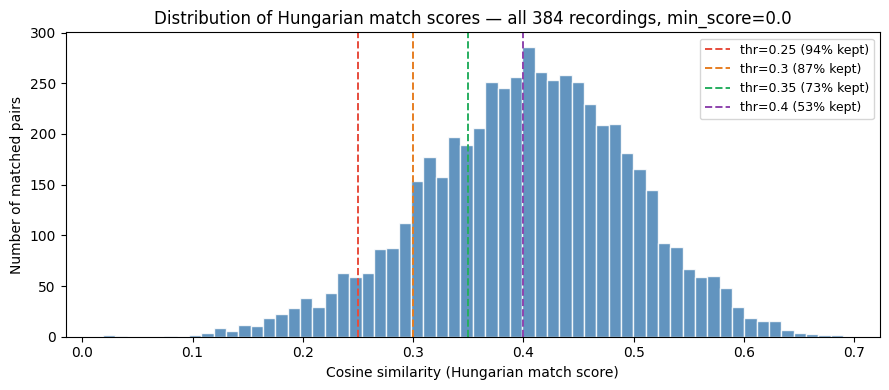


 Threshold    Pairs kept    % kept   Avg matched/graph   Avg text-only/graph
──────────────────────────────────────────────────────────────────────────────
      0.00          5492    100.0%                14.3                   0.5  ◀ current
      0.20          5368     97.7%                14.0                   0.8
      0.25          5159     93.9%                13.4                   1.4
      0.30          4769     86.8%                12.4                   2.4
      0.35          3983     72.5%                10.4                   4.4
      0.40          2931     53.4%                 7.6                   7.2
      0.45          1762     32.1%                 4.6                  10.2
      0.50           813     14.8%                 2.1                  12.7


In [21]:
# ── Global histogram + threshold table ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_match_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Cosine similarity (Hungarian match score)')
ax.set_ylabel('Number of matched pairs')
ax.set_title('Distribution of Hungarian match scores — all 384 recordings, min_score=0.0')
thresholds_to_show = [0.25, 0.30, 0.35, 0.40]
colors = ['#e74c3c', '#e67e22', '#27ae60', '#8e44ad']
for thr, col in zip(thresholds_to_show, colors):
    pct = 100 * (all_match_scores >= thr).mean()
    ax.axvline(thr, color=col, linestyle='--', linewidth=1.4,
               label=f'thr={thr} ({pct:.0f}% kept)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Threshold analysis table
print(f"\n{'Threshold':>10}  {'Pairs kept':>12}  {'% kept':>8}  "
      f"{'Avg matched/graph':>18}  {'Avg text-only/graph':>20}")
print('─' * 78)
for thr in [0.0, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    kept   = int((all_match_scores >= thr).sum())
    pct    = 100 * kept / len(all_match_scores)
    avg_m  = np.mean([sum(1 for s in r['scores'] if s >= thr) for r in per_rec_stats])
    avg_to = np.mean([r['n_nodes'] - sum(1 for s in r['scores'] if s >= thr)
                      for r in per_rec_stats])
    marker = '  ◀ current' if thr == 0.0 else ''
    print(f'{thr:>10.2f}  {kept:>12d}  {pct:>7.1f}%  {avg_m:>18.1f}  {avg_to:>20.1f}{marker}')

In [22]:
# ── Detailed view: best and worst recording by mean match score ───────────────
#
# Shows exactly which pairs Hungarian accepts and their scores,
# and how many survive at thr=0.35 vs thr=0.0.

# Pick one recording with high mean score and one with low mean score
sorted_recs   = sorted(per_rec_stats, key=lambda x: x['mean_score'])
examples      = [sorted_recs[0], sorted_recs[len(sorted_recs) // 2], sorted_recs[-1]]
labels        = ['WORST (lowest mean score)', 'MEDIAN', 'BEST (highest mean score)']

PREVIEW_THR = 0.35  # the threshold we are considering — change as needed

for ex, lbl in zip(examples, labels):
    rec_id     = ex['rec_id']
    tg         = task_graphs[ex['activity_id']]
    V          = np.load(
        Path(LOCAL_EMBEDDINGS_DIR) / f'{rec_id}_step_embeddings.npz'
    )['step_embeddings'].astype(np.float32)
    T          = text_cache[ex['activity_id']].numpy()
    sim        = compute_similarity_matrix(V, T)
    row_ids, col_ids = linear_sum_assignment(-sim)
    scores     = sim[row_ids, col_ids]

    kept  = sum(1 for s in scores if s >= PREVIEW_THR)
    total = len(scores)

    print(f'\n{"=" * 70}')
    print(f'[{lbl}]')
    print(f'Recording : {rec_id}  |  Recipe: {tg.activity_name}')
    print(f'N_vis={len(V)}, N_nodes={len(T)}, pairs={total}  '
          f'→  kept at thr={PREVIEW_THR}: {kept}/{total}')
    print(f'{"─" * 70}')
    print(f'{"vis":>5}  →  {"node":>5}  {"node text (truncated)":<40}  {"cosine":>7}  {"keep?"}')
    print(f'{"─" * 70}')
    for r, c, s in zip(row_ids, col_ids, scores):
        keep = '✓' if s >= PREVIEW_THR else '✗'
        print(f'{r:>5}  →  {c:>5}  {tg.nodes[c][:40]:<40}  {s:>7.3f}  {keep}')


[WORST (lowest mean score)]
Recording : 8_40  |  Recipe: Spiced Hot Chocolate
N_vis=19, N_nodes=7, pairs=7  →  kept at thr=0.35: 0/7
──────────────────────────────────────────────────────────────────────
  vis  →   node  node text (truncated)                      cosine  keep?
──────────────────────────────────────────────────────────────────────
    4  →      0  Heat-Heat the contents of the mug for 1     0.237  ✗
    5  →      1  Add-Add 1/5 teaspoon cinnamon to the mug    0.180  ✗
    6  →      3  Add-Add 1 teaspoon of white sugar to the    0.231  ✗
    7  →      6  Add-Add 2 pieces of chocolate to the mug    0.257  ✗
    8  →      4  Fill-Fill a microwave-safe mug with skim    0.319  ✗
   12  →      2  Mix-Mix the contents of the mug             0.292  ✗
   13  →      5  Microwave-Microwave the contents of the     0.280  ✗

[MEDIAN]
Recording : 23_38  |  Recipe: Broccoli Stir Fry
N_vis=48, N_nodes=25, pairs=25  →  kept at thr=0.35: 22/25
───────────────────────────────────────────

---
## Section 2 — Choose `sim_threshold`

Look at the histogram and the table above, then set `SIM_THRESHOLD` below.

- Pairs with cosine similarity **≥ SIM_THRESHOLD** → node gets fused text+visual features
- Pairs below the threshold → node stays **text-only** (no visual noise injected)

Suggested starting point: **0.35** (retains reliable matches, drops the noisy tail).

In [24]:
# ── EDIT THIS VALUE ───────────────────────────────────────────────────────────
SIM_THRESHOLD = 0.30
# ─────────────────────────────────────────────────────────────────────────────

# Cache directory name encodes the threshold (e.g., cache_thr035 for 0.30)
CACHE_DIR_NEW = f'{DRIVE_ROOT}/step3/cache_thr{int(SIM_THRESHOLD * 100):03d}'

# Quick summary of what this threshold implies
kept = int((all_match_scores >= SIM_THRESHOLD).sum())
pct  = 100 * kept / len(all_match_scores)
avg_m  = np.mean([sum(1 for s in r['scores'] if s >= SIM_THRESHOLD) for r in per_rec_stats])
avg_to = np.mean([r['n_nodes'] - sum(1 for s in r['scores'] if s >= SIM_THRESHOLD)
                  for r in per_rec_stats])
print(f'sim_threshold : {SIM_THRESHOLD}')
print(f'cache dir     : {CACHE_DIR_NEW}')
print(f'Pairs kept    : {kept}/{len(all_match_scores)} ({pct:.1f}%)')
print(f'Avg matched nodes/graph   : {avg_m:.1f}')
print(f'Avg text-only nodes/graph : {avg_to:.1f}')

sim_threshold : 0.3
cache dir     : /content/drive/MyDrive/AML_Project/step3/cache_thr030
Pairs kept    : 4769/5492 (86.8%)
Avg matched nodes/graph   : 12.4
Avg text-only nodes/graph : 2.4


---
## Section 3 — Build cache

We instantiate `TaskGraphDataset` with `sim_threshold=SIM_THRESHOLD` and a new
`cache_dir`. `prebuild_cache()` iterates over all 384 recordings, runs the
Hungarian matching (with threshold filtering), and saves one `.pt` file per
recording.

Each `.pt` file contains the pre-fusion fields ready for B4 training:
- `text_feats (N_nodes, 256)` — always filled (frozen EgoVLP text embeddings)
- `vis_feats  (N_nodes, 256)` — non-zero only for matched nodes above threshold
- `matched_mask (N_nodes,)` — True for nodes that received visual info
- `edge_index`, `y`, `num_nodes`

In [25]:
# ── Build pre-fusion cache with the chosen threshold ──────────────────────────

dataset = TaskGraphDataset(
    annotations_path    = ANNOTATIONS_PATH,
    step_embeddings_dir = LOCAL_EMBEDDINGS_DIR,  # local copy for speed
    graphs_dir          = GRAPHS_DIR,
    egovlp_repo         = EGOVLP_REPO,
    egovlp_ckpt         = EGOVLP_CKPT,
    cache_dir           = CACHE_DIR_NEW,
    sim_threshold       = SIM_THRESHOLD,
)

print(f'Building cache in: {CACHE_DIR_NEW}')
print(f'Dataset size     : {len(dataset)} recordings')
dataset.prebuild_cache()
print('Done.')

Loaded 24 task graphs (0 missing) from /content/code/annotations/task_graphs
Building cache in: /content/drive/MyDrive/AML_Project/step3/cache_thr030
Dataset size     : 384 recordings
[TaskGraphDataset] Building cache for 384 items...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


######USING ATTENTION STYLE:  frozen-in-time
### loaded SpaceTimeTransformer model has MORE frames than current...### loading weights, filling in the extras via zeros
  50/384 done
  100/384 done
  150/384 done
  200/384 done
  250/384 done
  300/384 done
  350/384 done
[TaskGraphDataset] Cache build complete.
Done.


In [26]:
# ── Verify cache ──────────────────────────────────────────────────────────────

cache_files = sorted(Path(CACHE_DIR_NEW).glob('*.pt'))
print(f'Cache files: {len(cache_files)} / 384 expected')

# Inspect one sample
sample = torch.load(cache_files[0], weights_only=False)
print(f'\nSample: {cache_files[0].stem}')
print(f'  text_feats   : {sample.text_feats.shape}')
print(f'  vis_feats    : {sample.vis_feats.shape}')
print(f'  matched_mask : {sample.matched_mask.shape}  '
      f'({sample.matched_mask.sum().item()}/{len(sample.matched_mask)} matched)')
print(f'  edge_index   : {sample.edge_index.shape}')
print(f'  y            : {sample.y.item()}')

# Global matched-node statistics across all cache files
total_nodes   = 0
total_matched = 0
for pt in cache_files:
    d = torch.load(pt, weights_only=False)
    total_nodes   += len(d.matched_mask)
    total_matched += int(d.matched_mask.sum())

total_text_only = total_nodes - total_matched
print(f'\nGlobal matched nodes   : {total_matched}/{total_nodes} '
      f'({100 * total_matched / total_nodes:.1f}%)')
print(f'Global text-only nodes : {total_text_only}/{total_nodes} '
      f'({100 * total_text_only / total_nodes:.1f}%)')
print(f'\nCache ready at: {CACHE_DIR_NEW}')
print(f'Pass to gnn_task_classifier.ipynb as CACHE_DIR = "{CACHE_DIR_NEW}"')

Cache files: 384 / 384 expected

Sample: 10_16
  text_feats   : torch.Size([19, 256])
  vis_feats    : torch.Size([19, 256])
  matched_mask : torch.Size([19])  (13/19 matched)
  edge_index   : torch.Size([2, 18])
  y            : 0.0

Global matched nodes   : 4769/5684 (83.9%)
Global text-only nodes : 915/5684 (16.1%)

Cache ready at: /content/drive/MyDrive/AML_Project/step3/cache_thr030
Pass to gnn_task_classifier.ipynb as CACHE_DIR = "/content/drive/MyDrive/AML_Project/step3/cache_thr030"
